# MİNİ PROJE 2: Embedding (Anlamsal Gömme) Karşılaştırması

**Amaç:** RAG mimarisinin temelini oluşturan vektör dönüştürme işlemini göstermek. Kelimeleri farklı ama anlamı aynı olan cümlelerin, alakasız cümlelere göre matematiksel olarak ne kadar yakın olduğunu "Kosinüs Benzerliği" ile ispatlayacağız.

In [3]:
# Gerekli yapay zeka kütüphanesini Colab sunucusuna kuruyoruz
!pip install sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

# Veri Yükleme: Test edeceğimiz cümleler
cumleler = [
    "C programlamada spesifik bir biti 1 yapmak (Set) için bit masking teknikleri kullanılır.", # Yazılım 1
    "Mikrodenetleyici kodlarında istediğimiz bitin durumunu değiştirmek amacıyla operatörler tercih edilir.", # Yazılım 2
    "Polo classic araçlarda düz 1.6 motor seçenekleri piyasada çok tutuluyor.", # Otomotiv
    "Paralel bağlı kollardaki gerilim değerleri her zaman birbirine eşittir." # Elektrik
]
print("Veriler yüklendi!")

Veriler yüklendi!


### Model Kurulumu ve Eğitim (Encoding)
**Bu hücre ne yapıyor?** Türkçe destekli HuggingFace modelini indirir ve yukarıdaki metinleri makinenin anlayacağı yüzlerce boyutlu matematiksel vektörlere çevirir.

In [4]:
# Modeli yüklüyoruz ve cümleleri vektörlere çeviriyoruz
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
vektorler = model.encode(cumleler)

print("Cümleler başarıyla matematiksel koordinatlara (vektörlere) dönüştürüldü.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Cümleler başarıyla matematiksel koordinatlara (vektörlere) dönüştürüldü.


### Sonuçlar ve Isı Haritası (Heatmap)
**Bu hücre ne yapıyor?** Vektörler arasındaki Kosinüs Benzerliğini hesaplar ve hocamızın inceleyebilmesi için renkli bir Isı Haritası grafiği çizer.

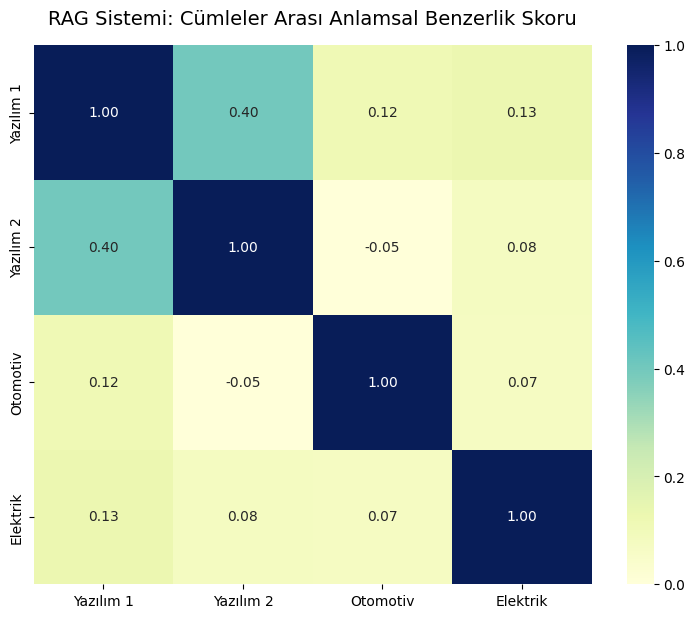

In [5]:
# Benzerliklerin Hesaplanması
benzerlik_matrisi = cosine_similarity(vektorler)

# Grafiğin çizdirilmesi
plt.figure(figsize=(9, 7))
sns.heatmap(benzerlik_matrisi, annot=True, cmap="YlGnBu", fmt=".2f", vmin=0, vmax=1,
            xticklabels=["Yazılım 1", "Yazılım 2", "Otomotiv", "Elektrik"],
            yticklabels=["Yazılım 1", "Yazılım 2", "Otomotiv", "Elektrik"])

plt.title("RAG Sistemi: Cümleler Arası Anlamsal Benzerlik Skoru", fontsize=14, pad=15)
plt.show()